# Uzbek-Language Telegram Job Market in South Korea

This notebook measures the advertised Uzbek-speaking Telegram job market. It describes advertisements, not the entire Korean labor market, and does not infer individual workers' legal status.

In [7]:
import json
import pandas as pd
from pathlib import Path


def find_raw_path() -> Path:
    for candidate in (Path("data/raw"), Path("../../data/raw")):
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not find data/raw")


def extract_chat_id(message: dict) -> int | None:
    chat_id = message.get("chat_id")
    if isinstance(chat_id, int):
        return chat_id
    peer_id = message.get("peer_id")
    if isinstance(peer_id, dict):
        for key in ("channel_id", "chat_id", "user_id"):
            if isinstance(peer_id.get(key), int):
                return peer_id[key]
    return None


DATASET_PATH = find_raw_path()
records = []

for source_path in sorted(DATASET_PATH.glob("*.jsonl")):
    with source_path.open("r", encoding="utf-8") as source:
        for line_number, line in enumerate(source, start=1):
            try:
                message = json.loads(line)
            except json.JSONDecodeError:
                continue
            text = str(message.get("message", "")).strip()
            records.append(
                {
                    "source_group": source_path.stem,
                    "source_file": source_path.name,
                    "source_line": line_number,
                    "msg_id": message.get("id"),
                    "chat_id": extract_chat_id(message),
                    "message_user_id": message.get("sender_id"),
                    "date": pd.to_datetime(message.get("date"), unit="s", utc=True, errors="coerce"),
                    "text": text,
                }
            )

messages = pd.DataFrame(records)
if messages.empty:
    raise ValueError(f"No JSONL messages found in {DATASET_PATH}")

messages["month"] = messages["date"].dt.to_period("M").astype("string")
messages["year"] = messages["date"].dt.year.astype("Int64")
messages["is_duplicate"] = messages.duplicated(["chat_id", "msg_id"], keep="first")
unique_messages = messages.loc[~messages["is_duplicate"]].copy()

print(f"Raw advertisements: {len(messages):,}")
print(f"Unique advertisements: {len(unique_messages):,}")
print(f"Duplicate rows: {messages['is_duplicate'].sum():,}")
unique_messages.head(3)

Raw advertisements: 198,058
Unique advertisements: 198,058
Duplicate rows: 0


/var/folders/zw/s4120bc94vdcwd8bd80yw_j80000gn/T/ipykernel_73209/1462799952.py:53: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  messages["month"] = messages["date"].dt.to_period("M").astype("string")


,source_group,source_file,source_line,msg_id,chat_id,message_user_id,date,text,month,year,is_duplicate
0,group_-1001141152967,group_-1001141152967.jsonl,1,51260,1141152967,None,2026-09-24 13:18:56+00:00,Xamirli taomlar tayyorlash bo‘yicha povar kera...,2026-09,2026,False
1,group_-1001141152967,group_-1001141152967.jsonl,2,51259,1141152967,None,2026-09-24 11:00:01+00:00,Sheriklikga 2 kishi bor,2026-09,2026,False
2,group_-1001141152967,group_-1001141152967.jsonl,3,51258,1141152967,None,2026-09-24 08:15:19+00:00,Hozir,2026-09,2026,False


In [8]:
import re

In [9]:
import sys

PROJECT_ROOT = DATASET_PATH.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.analysis.locations import load_group_locations, resolve_location

# Location = first Korean address in the post body; otherwise the group's province/city.
GROUP_LOCATIONS = load_group_locations(PROJECT_ROOT / "data" / "telegram_groups.csv")

OCCUPATION_KEYWORDS = {
    "factory": ["factory", "zavod", "공장", "생산"],
    "restaurant": ["restaurant", "restoran", "식당", "주방", "주방장"],
    "construction": ["construction", "qurilish", "건설", "현장"],
    "agriculture": ["farm", "ferma", "농장", "농업", "dalada"],
    "warehouse": ["warehouse", "ombor", "물류", "창고"],
    "delivery": ["delivery", "배달", "쿠팡"],
    "cleaning": ["cleaning", "tozalash", "청소"],
}

VISA_PATTERN = re.compile(r"\b(?:E[- ]?9|H[- ]?2|F[- ]?[46]|D[- ]?2|E[- ]?7|E[- ]?8)\b", re.IGNORECASE)
SALARY_PATTERN = re.compile(r"(?P<amount>\d{1,3}(?:[,.]\d{3})+|\d{4,})\s*(?:won|원)", re.IGNORECASE)


def matching_labels(text: str, keywords: dict[str, list[str]]) -> str:
    lowered = text.lower()
    return ";".join(label for label, terms in keywords.items() if any(term.lower() in lowered for term in terms))


def extract_salary(text: str) -> tuple[int | None, str]:
    match = SALARY_PATTERN.search(text)
    if not match:
        return None, ""
    amount = int(match.group("amount").replace(",", "").replace(".", ""))
    context = text[max(0, match.start() - 30):match.end() + 30].lower()
    if any(term in context for term in ("hour", "soat", "시급", "시간")):
        period = "hourly"
    elif any(term in context for term in ("day", "kun", "일급", "하루")):
        period = "daily"
    elif any(term in context for term in ("month", "oylik", "월급", "월")):
        period = "monthly"
    else:
        period = "unknown"
    return amount, period


def enrich(row: pd.Series) -> pd.Series:
    salary, salary_period = extract_salary(row["text"])
    province, city, location_source = resolve_location(row["text"], row["source_file"], GROUP_LOCATIONS)
    return pd.Series(
        {
            "province": province,
            "city": city,
            "location_source": location_source,
            "occupations": matching_labels(row["text"], OCCUPATION_KEYWORDS),
            "visa_statuses": ";".join(sorted(set(VISA_PATTERN.findall(row["text"])), key=str.lower)),
            "salary_krw": salary,
            "salary_period": salary_period,
            "has_accommodation": any(term in row["text"].lower() for term in ("숙소", "기숙사", "accommodation", "yotoqxona")),
            "has_meals": any(term in row["text"].lower() for term in ("식사", "밥 제공", "meal", "ovqat")),
            "requires_korean": any(term in row["text"].lower() for term in ("한국어", "korean", "koreys tili")),
        }
    )


features = unique_messages.join(unique_messages.apply(enrich, axis=1))
features[["province", "city", "location_source", "occupations", "visa_statuses", "salary_period"]].head()

,locations,occupations,visa_statuses,salary_period
0,,,,
1,,,,
2,,,,
3,,,,
4,,,,


In [10]:
def canonicalize_visa(value: str) -> str:
    return re.sub(r"[-\s]", "", value).upper()


features["visa_statuses"] = features["visa_statuses"].apply(
    lambda value: ";".join(sorted({canonicalize_visa(item) for item in value.split(";") if item}))
)
features["visa_statuses"].value_counts().head(10)

visa_statuses
               192752
E9               1903
D2                841
D2;E9             363
F4;F6             319
D2;E9;F4;F6       252
E7                229
H2                219
E7;E9             157
D2;E7;E9          151
Name: count, dtype: int64

In [11]:
def exploded_counts(frame: pd.DataFrame, column: str) -> pd.DataFrame:
    values = frame[[column]].assign(label=frame[column].str.split(";")).explode("label")
    values = values[values["label"].notna() & values["label"].ne("")]
    return values.groupby("label").size().sort_values(ascending=False).rename("advertisements").to_frame()


print("Advertisements by month")
display(features.groupby("month").size().rename("advertisements").to_frame())

print("Location source (address in post vs. group fallback)")
display(features["location_source"].value_counts().rename("advertisements").to_frame())

located = features[features["province"].ne("")]
print("Advertisements by province")
display(located.groupby("province").size().sort_values(ascending=False).rename("advertisements").to_frame())

print("Top 20 cities")
display(
    located[located["city"].ne("")]
    .groupby(["province", "city"]).size().sort_values(ascending=False).head(20)
    .rename("advertisements").to_frame()
)

print("Advertisements by occupation")
display(exploded_counts(features, "occupations"))

print("Advertisements by advertised visa status")
display(exploded_counts(features, "visa_statuses"))

print("Median salary by period")
display(
    features.dropna(subset=["salary_krw"])
    .groupby("salary_period")["salary_krw"]
    .agg(advertisements="size", median_krw="median")
    .sort_values("advertisements", ascending=False)
)

print("Province x occupation")
location_occupation = (
    located.assign(occupation=located["occupations"].str.split(";"))
    .explode("occupation")
    .reset_index(drop=True)
)
location_occupation = location_occupation[location_occupation["occupation"].fillna("").ne("")]
display(pd.crosstab(location_occupation["province"], location_occupation["occupation"]))

Advertisements by month


,advertisements
month,
2021-01,144
2021-02,392
2021-03,2028
2021-04,780
2021-05,666
...,...
2026-05,5146
2026-06,5155
2026-07,5293


Advertisements by location


,advertisements
label,
Mokpo,5363
Incheon,4409
Daegu,4223
Seoul,3838
Gyeonggi,2620
Busan,779
Chungnam,501
Daejeon,412
Jeju,93


Advertisements by occupation


...

,advertisements
label,
E9,3115
D2,2028
F4,1203
F6,906
H2,751
E7,702
E8,18


Median salary by period


,advertisements,median_krw
salary_period,,
unknown,2245,85000.0
hourly,499,130000.0
daily,422,150000.0
monthly,263,69000.0


Location x occupation


occupation,,agriculture,cleaning,construction,delivery,factory,restaurant,warehouse
location,,,,,,,,
,175502,134,104,200,26,3183,170,76
Busan,738,2,4,6,0,34,3,0
Chungnam,416,8,2,2,0,78,2,8
Daegu,4043,10,19,5,2,135,14,0
Daejeon,399,2,0,2,0,6,3,0
Gyeonggi,2406,6,8,21,3,194,3,15
Incheon,4323,0,19,9,0,57,1,2
Jeju,83,0,0,0,0,7,3,0
Mokpo,5238,12,10,13,0,87,11,1


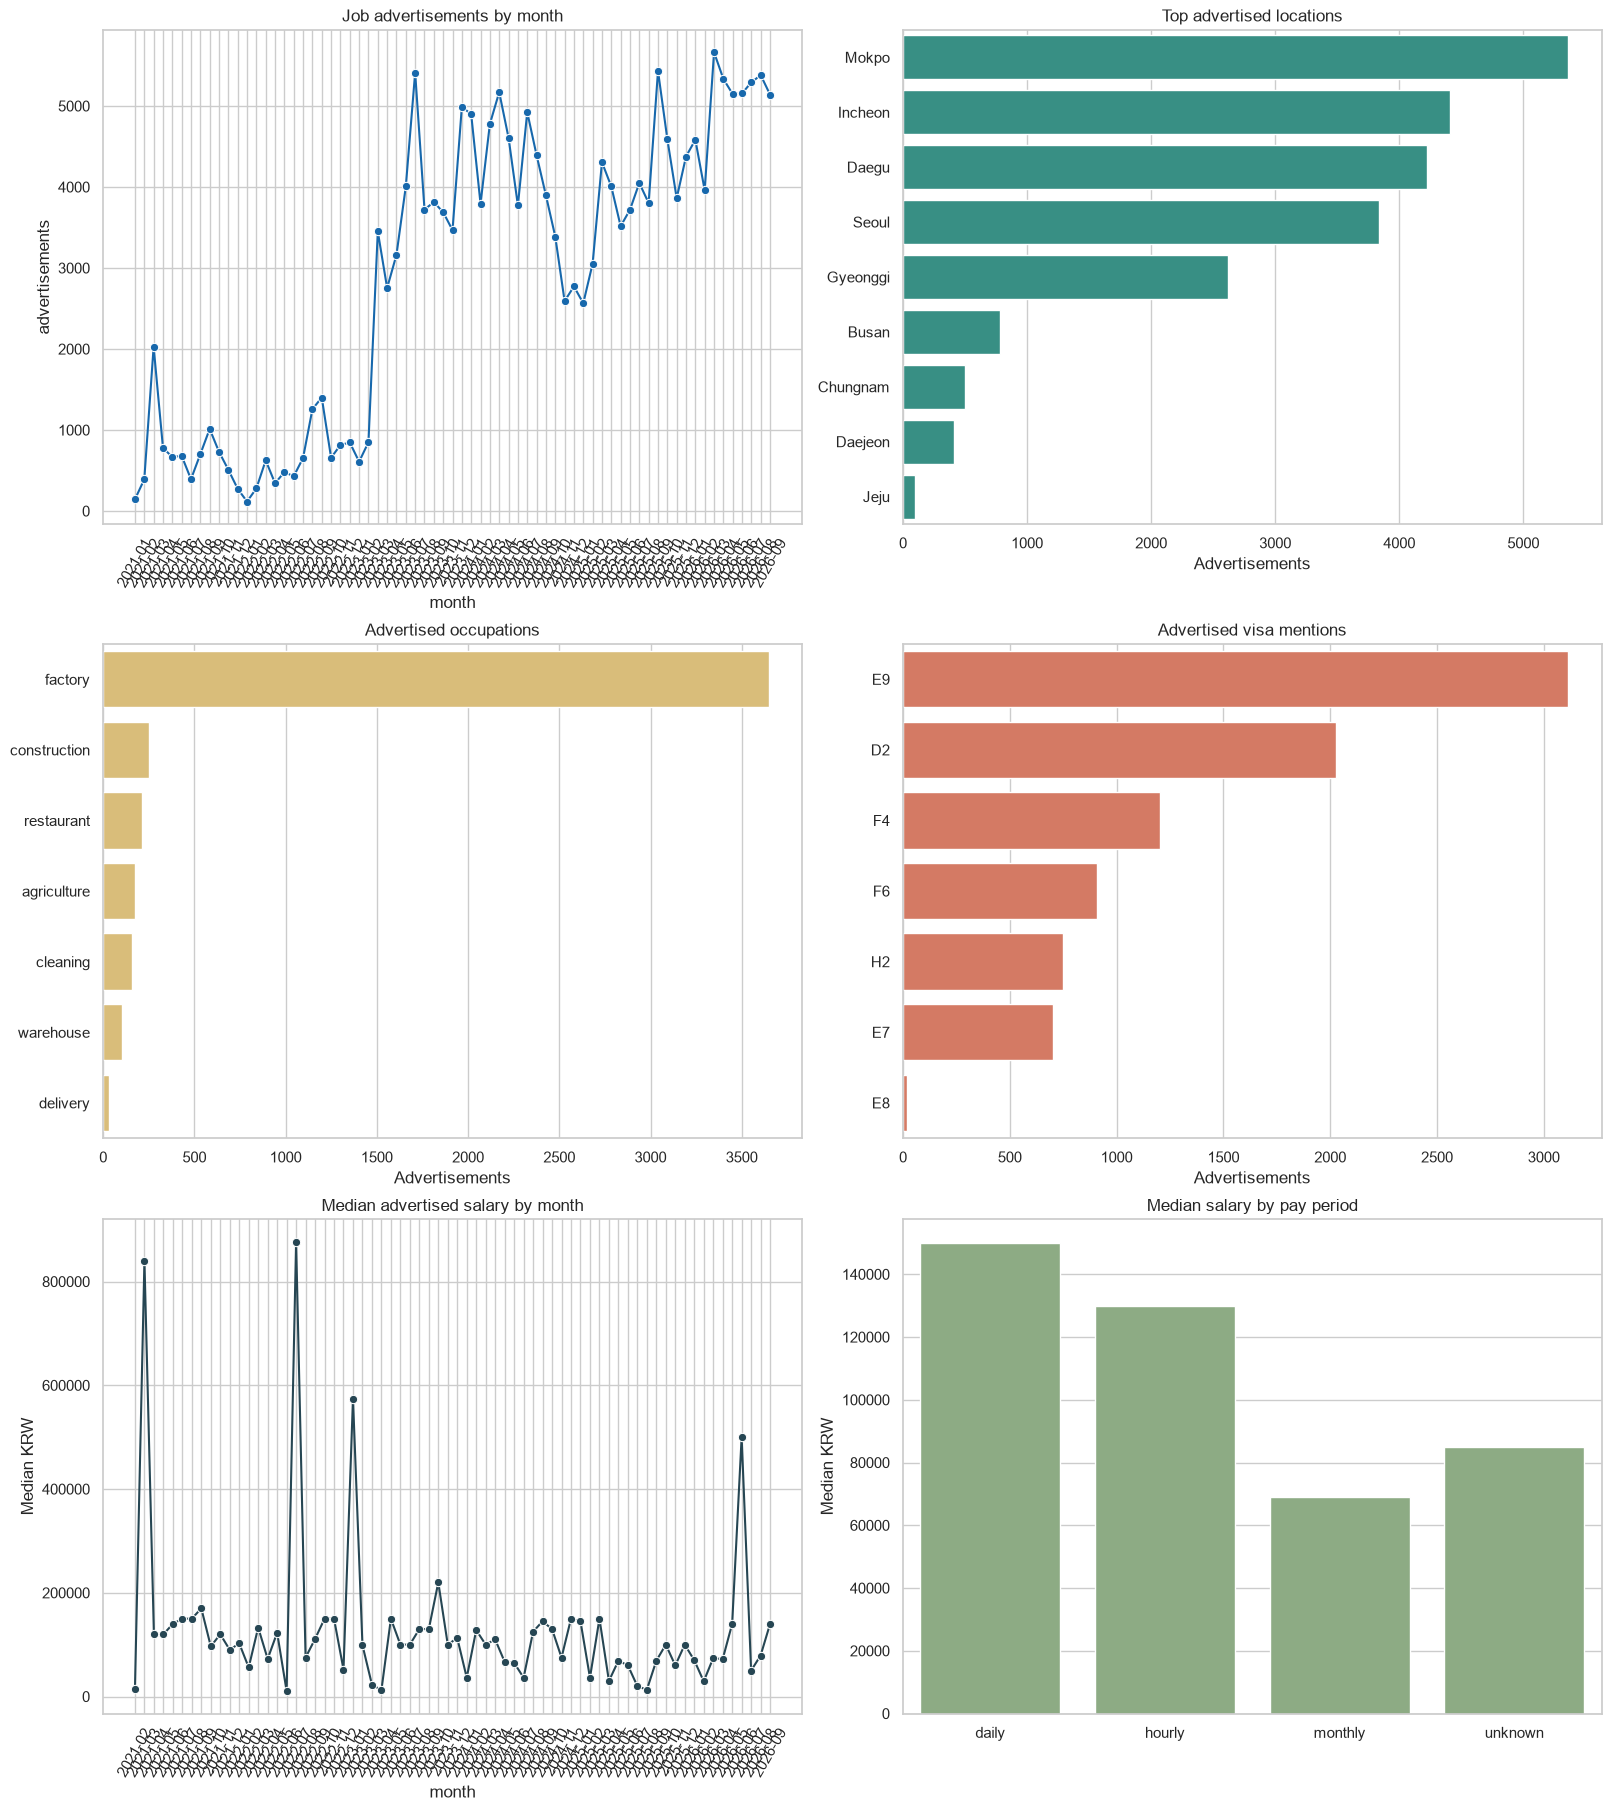

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

monthly = features.groupby("month").size().rename("advertisements").reset_index()
location_counts = located.groupby("province").size().sort_values(ascending=False).head(10).rename("advertisements").rename_axis("label").reset_index()
occupation_counts = exploded_counts(features, "occupations").reset_index()
visa_counts = exploded_counts(features, "visa_statuses").head(10).reset_index()
salary_monthly = (
    features.dropna(subset=["salary_krw"])
    .groupby("month", as_index=False)["salary_krw"]
    .median()
)

fig, axes = plt.subplots(3, 2, figsize=(16, 18), constrained_layout=True)

sns.lineplot(data=monthly, x="month", y="advertisements", marker="o", ax=axes[0, 0], color="#1768ac")
axes[0, 0].set_title("Job advertisements by month")
axes[0, 0].tick_params(axis="x", rotation=60)

sns.barplot(data=location_counts, y="label", x="advertisements", ax=axes[0, 1], color="#2a9d8f")
axes[0, 1].set_title("Top advertised provinces")
axes[0, 1].set_xlabel("Advertisements")
axes[0, 1].set_ylabel("")

sns.barplot(data=occupation_counts, y="label", x="advertisements", ax=axes[1, 0], color="#e9c46a")
axes[1, 0].set_title("Advertised occupations")
axes[1, 0].set_xlabel("Advertisements")
axes[1, 0].set_ylabel("")

sns.barplot(data=visa_counts, y="label", x="advertisements", ax=axes[1, 1], color="#e76f51")
axes[1, 1].set_title("Advertised visa mentions")
axes[1, 1].set_xlabel("Advertisements")
axes[1, 1].set_ylabel("")

sns.lineplot(data=salary_monthly, x="month", y="salary_krw", marker="o", ax=axes[2, 0], color="#264653")
axes[2, 0].set_title("Median advertised salary by month")
axes[2, 0].set_ylabel("Median KRW")
axes[2, 0].tick_params(axis="x", rotation=60)

salary_period = (
    features.dropna(subset=["salary_krw"])
    .groupby("salary_period", as_index=False)["salary_krw"]
    .median()
)
sns.barplot(data=salary_period, x="salary_period", y="salary_krw", ax=axes[2, 1], color="#8ab17d")
axes[2, 1].set_title("Median salary by pay period")
axes[2, 1].set_ylabel("Median KRW")
axes[2, 1].set_xlabel("")

plt.show()